In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import linalg as la
from tqdm import tqdm
import pickle
import seaborn as sns

# import cmasher as cmr
# import kwant

from koala import plotting as pl

from alter_morph.mean_field import hartree_fock

# from alter_morph.kwant_utilities import (
#     crack_hamiltonian_for_contacts_kwant,
#     attach_leads_to_cracked,
# )
from alter_morph.hamiltonians import (
    alt_hamiltonian,
    spectral_function,
    _hopping_matrix,
    find_m_per_state,
    find_spin_per_state,
    spectral_path,
)

aps_figwidth = 3.375 * 2
aps_halfwidth = 3.375

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)

In [18]:
def fermi_level(energies, filling):
    return np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [19]:
data_name = "data/detailed_phase_diagram_20_V0"
lattice_name = "analysis/voronoi_20"
# load data
with open(data_name + ".pickle", "rb") as f:
    data = pickle.load(f)

# load lattice
with open(lattice_name + ".pickle", "rb") as f:
    lattice = pickle.load(f)

In [20]:
# process the data

fillings = data["filling"]
J_vals = data["J"]

all_avg_mags = np.zeros([len(fillings), len(J_vals)])
all_variance_mags = np.zeros([len(fillings), len(J_vals)])

all_bond_diff_m = np.zeros([len(fillings), len(J_vals)])
all_bond_diff_n = np.zeros([len(fillings), len(J_vals)])
all_prop_relative_m = np.zeros([len(fillings), len(J_vals)])

all_energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])
broadening = 0.1

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):
        current_data = data["params"][i, j]

        # calculate the average magnetization
        all_avg_mags[i, j] = np.mean(current_data["m"])
        all_variance_mags[i, j] = np.var(current_data["n"])

        all_prop_relative_m[i, j] = np.mean(current_data["m"]) / np.max(
            current_data["m"]
        )

        all_energies[i, j] = data["data"][i, j]["energies"]

        # # calculate the density of states
        # all_dos_vals[i, j] = dos_at_fermi(
        #     all_energies[i, j], fermi_level(all_energies[i, j], filling), broadening
        # )

        # difference in m on bonds
        m = data["params"][i, j]["m"]
        m_on_bonds = m[lattice.edges.indices]
        all_bond_diff_m[i, j] = np.abs(m_on_bonds[:, 0] - m_on_bonds[:, 1]).mean()

        # difference in n on bonds
        n = data["params"][i, j]["n"]
        n_on_bonds = n[lattice.edges.indices]
        all_bond_diff_n[i, j] = np.abs(n_on_bonds[:, 0] - n_on_bonds[:, 1]).mean()

100%|██████████| 41/41 [00:00<00:00, 287.62it/s]


In [21]:
point_A = (0.1, 0.5)
point_B = (0.6, 0.15)
point_C = (0.6, 0.85)

points = [point_A, point_B, point_C]
argpoints = []
for i in range(3):
    point = points[i]
    arg_J = np.argmin(np.abs(J_vals - point[0]))
    arg_filling = np.argmin(np.abs(fillings - point[1]))
    argpoints.append((arg_J, arg_filling))
    point = (J_vals[arg_J], fillings[arg_filling])
    points[i] = point

In [28]:
broadening = 0.2
nk = 200
n_energy = 20
n_path = 30
path = np.array([[1, 1], [1, 0], [0, 0], [0, 1], [1, 1]])

combined = []
spin_resolved = []
spin_up = []
spin_down = []
spectral_paths = []
spectral_paths_diffs = []
each_energies = []
each_fermi_level = []


for i in range(3):
    j_arg, fil_arg = argpoints[i]

    parameters_at_point = data["params"][fil_arg, j_arg]
    parameters_for_run = {
        "t1": parameters_at_point["t1"],
        "t2": parameters_at_point["t2"],
        "J": parameters_at_point["J"],
        "U": parameters_at_point["U"],
        "filling": parameters_at_point["filling"],
        "initial_m": parameters_at_point["m"],
        "initial_n": parameters_at_point["n"],
        "theta_offset": 0,
    }
    hamiltonian_at_point = alt_hamiltonian(
        lattice,
        parameters_for_run["t1"],
        parameters_for_run["t2"],
        parameters_for_run["J"],
        parameters_for_run["U"],
        parameters_for_run["initial_m"],
        parameters_for_run["initial_n"],
        parameters_for_run["theta_offset"],
    )

    energies_at_point, states_at_point = la.eigh(hamiltonian_at_point)

    fermi_energy_at_point = fermi_level(
        energies_at_point, parameters_for_run["filling"]
    )

    specs_at_point = [
        spectral_function(
            lattice,
            energies_at_point,
            states_at_point,
            fermi_energy_at_point,
            local_operator=np.eye(4)[i],
            eta=broadening,
            n_k=nk,
        )
        for i in range(4)
    ]

    spectral_path_at_point = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=0.1,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, 1, 1]),
        path=path,
    )
    spectral_path_at_point_diff = spectral_path(
        lattice,
        energies_at_point,
        states_at_point,
        eta=0.1,
        n_k=n_path,
        n_energy=n_energy,
        local_operator=np.array([1, 1, -1, -1]),
        path=path,
    )

    spectral_paths.append(spectral_path_at_point)
    spectral_paths_diffs.append(spectral_path_at_point_diff)

    combined.append(np.sum(specs_at_point, axis=0))
    spin_resolved.append(
        specs_at_point[0] + specs_at_point[1] - specs_at_point[2] - specs_at_point[3]
    )
    spin_up.append(specs_at_point[0] + specs_at_point[1])
    spin_down.append(specs_at_point[2] + specs_at_point[3])

    each_energies.append(energies_at_point)
    each_fermi_level.append(fermi_energy_at_point)

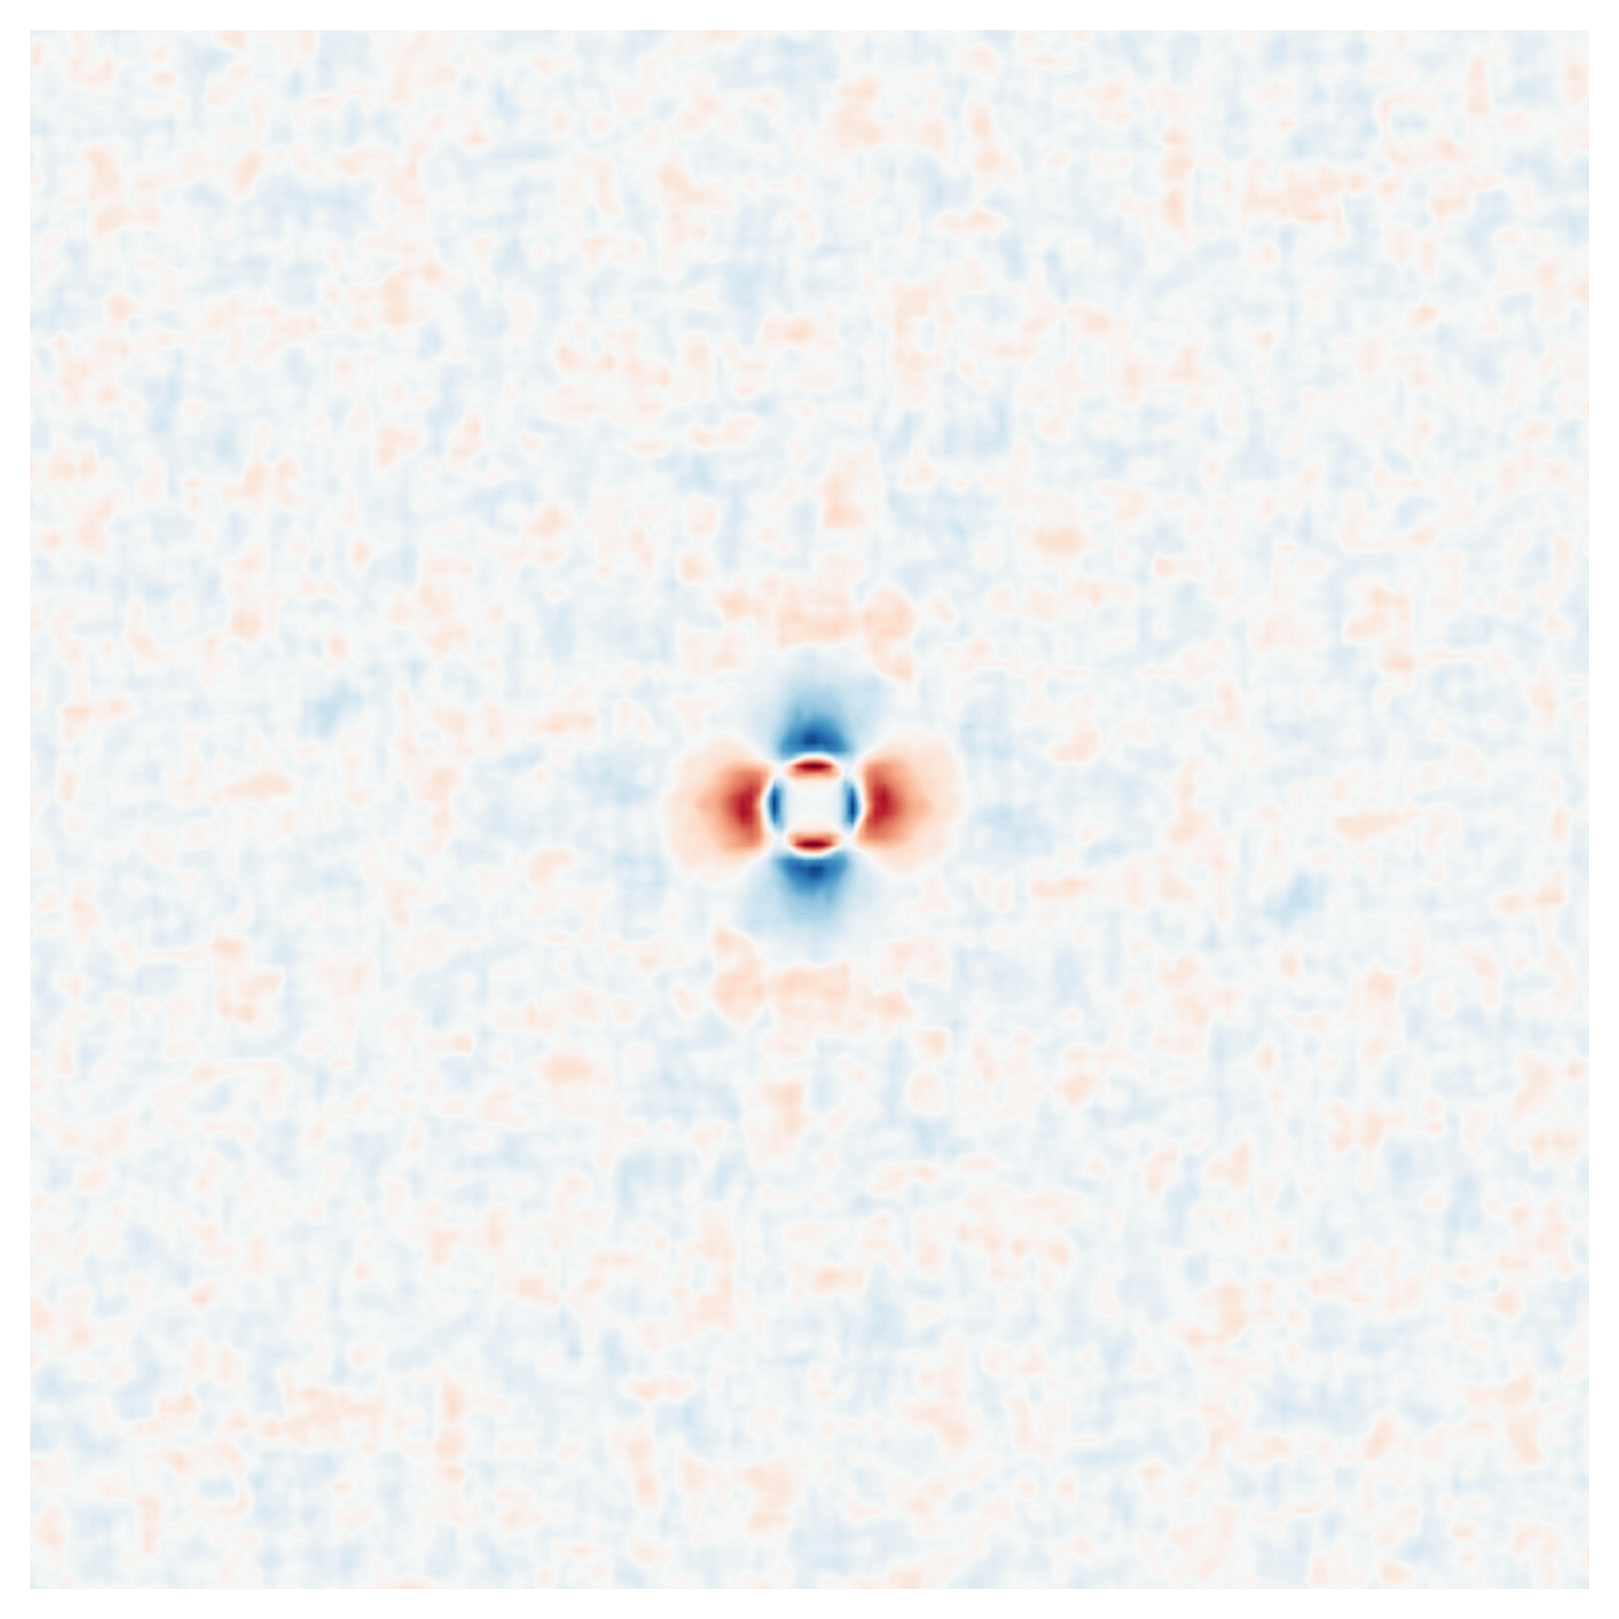

In [30]:
max_comb, min_comb = np.max(combined), np.min(combined)
max_spin, min_spin = np.max(spin_resolved), np.min(spin_resolved)
min_down, max_down = np.min(spin_down), np.max(spin_down)
min_up, max_up = np.min(spin_up), np.max(spin_up)

k_vals = np.arange(-nk // 2, nk // 2) * 2 * np.pi
ks = np.array(np.meshgrid(k_vals, k_vals))


fig, ax = plt.subplots(
    1, 1, figsize=(aps_figwidth, aps_figwidth), dpi=300, sharex=True, sharey=True
)


ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
# remove border
ax.set_axis_off()

ax.contourf(
    ks[0],
    ks[1],
    spin_resolved[1],
    cmap="RdBu_r",
    origin="lower",
    levels=100,
    vmin=min_spin,
    vmax=max_spin,
)

plt.savefig("talk_figs/front.png")